<a href="https://colab.research.google.com/github/pactiones/Treinamento-em-IA/blob/main/Aula4/EDA/Exercicio_1_Iris_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%cd "/content/drive/MyDrive/Atividade 1 - Iris"

/content/drive/MyDrive/Atividade 1 - Iris


#Exercicio Iris - Mateus Pactiones

In [ ]:
from sklearn.datasets import load_iris
import pandas as pd
import matplotlib.pyplot as plt

iris = load_iris(as_frame=True)
df_iris = iris.frame

df_iris["species"] = df_iris["target"].map(
    dict(enumerate(iris.target_names))
)

In [ ]:
print("Primeiras linhas:")
print(df_iris.head())

print("\nQuantidade de linhas e colunas:")
print(df_iris.shape)

print("\nNomes das colunas:")
print(df_iris.columns.tolist())

Primeiras linhas:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species  
0       0  setosa  
1       0  setosa  
2       0  setosa  
3       0  setosa  
4       0  setosa  

Quantidade de linhas e colunas:
(150, 6)

Nomes das colunas:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'target', 'species']


In [ ]:
df_iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species            150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [ ]:
print("Valores ausentes por coluna:")
print(df_iris.isnull().sum())

print("Qualidade de linhas duplicadas:")
print(df_iris.duplicated().sum())

Valores ausentes por coluna:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64
Qualidade de linhas duplicadas:
1


In [ ]:
print(df_iris.describe())

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)      target  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  


In [ ]:
print("Quantidade de flores por espécie:")
print(df_iris["species"].value_counts())

Quantidade de flores por espécie:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [ ]:
print("Média das medidas por espécie:")

medias_por_especie = df_iris.groupby("species")[iris.feature_names].mean()

print(medias_por_especie.round(2))

Média das medidas por espécie:
            sepal length (cm)  sepal width (cm)  petal length (cm)  \
species                                                              
setosa                   5.01              3.43               1.46   
versicolor               5.94              2.77               4.26   
virginica                6.59              2.97               5.55   

            petal width (cm)  
species                       
setosa                  0.25  
versicolor              1.33  
virginica               2.03  


Gráfico em barras




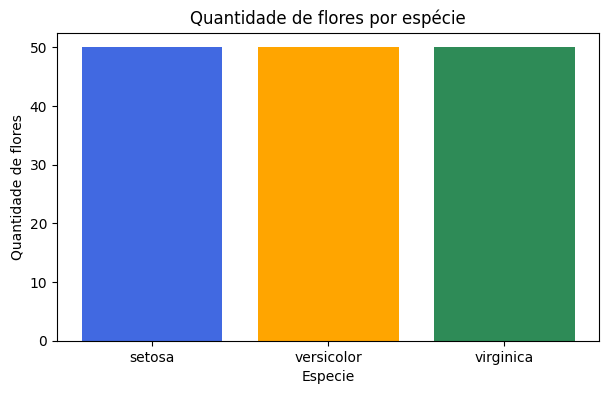

In [ ]:
print("Gráfico em barras")
print("\n")

ordem = list(iris.target_names)

quantidade = (
    df_iris["species"].value_counts().reindex(ordem)
)

plt.figure(figsize = (7,4))
plt.bar(
    quantidade.index, quantidade.values, color = ["royalblue", "orange", "seagreen"]
)

plt.xlabel("Especie")
plt.ylabel("Quantidade de flores")
plt.title("Quantidade de flores por espécie")
plt.show()

Gráfico de histograma




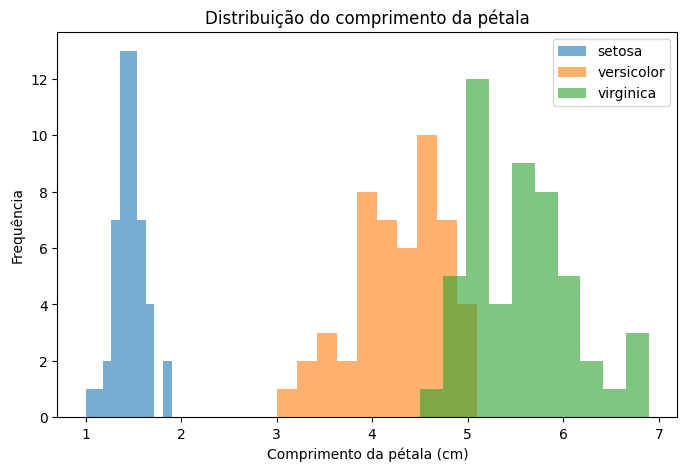

In [ ]:
print("Gráfico de histograma")
print("\n")

plt.figure(figsize = (8,5))

for especie in iris.target_names:
  dados = df_iris.loc[df_iris["species"] == especie, "petal length (cm)"]

  plt.hist(dados, bins = 10, alpha = 0.6, label = especie)

plt.xlabel("Comprimento da pétala (cm)")
plt.ylabel("Frequência")
plt.title("Distribuição do comprimento da pétala")
plt.legend()
plt.show()

Gráfico de dispersão




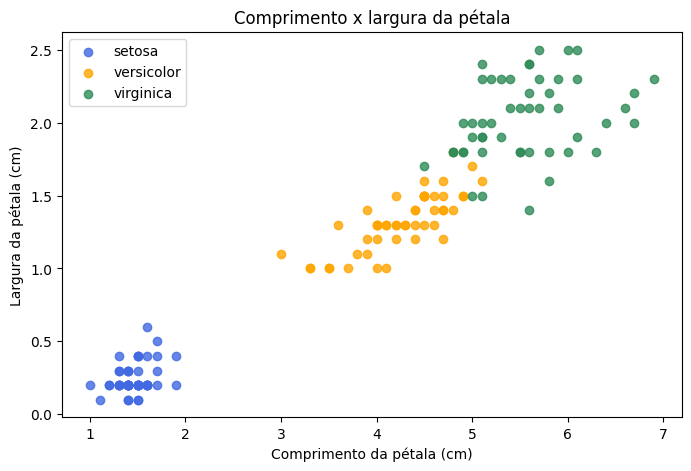

In [ ]:
print("Gráfico de dispersão")
print("\n")

cores = {
    "setosa": "royalblue",
    "versicolor": "orange",
    "virginica": "seagreen"
}

plt.figure(figsize=(8,5))

for especie in iris.target_names:
  dados = df_iris[df_iris["species"] == especie]

  plt.scatter(
      dados["petal length (cm)"],
      dados["petal width (cm)"],
      label=especie,
      color=cores[especie],
      alpha = 0.8
  )

plt.xlabel("Comprimento da pétala (cm)")
plt.ylabel("Largura da pétala (cm)")
plt.title("Comprimento x largura da pétala")
plt.legend()
plt.show()

<Figure size 800x500 with 0 Axes>

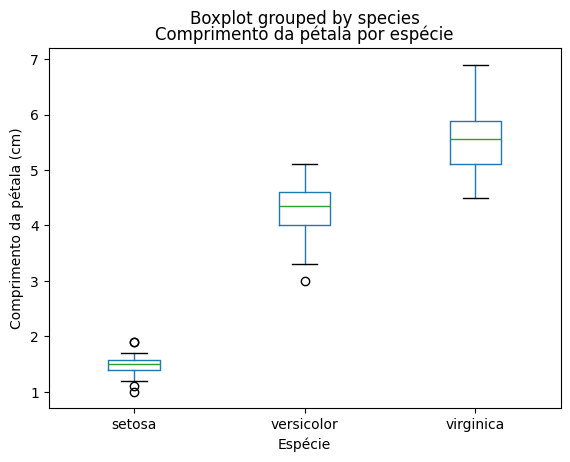

In [ ]:
plt.figure(figsize=(8,5))

df_iris.boxplot(
    column="petal length (cm)",
    by="species",
    grid=False
)

plt.xlabel("Espécie")
plt.ylabel("Comprimento da pétala (cm)")
plt.title("Comprimento da pétala por espécie")
plt.show()

In [ ]:
variaveis_numericas = iris.feature_names

correlacao = df_iris[variaveis_numericas].corr()

print("Correlação entre as variáveis:")
print(correlacao.round(2))

Correlação entre as variáveis:
                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)               1.00             -0.12               0.87   
sepal width (cm)               -0.12              1.00              -0.43   
petal length (cm)               0.87             -0.43               1.00   
petal width (cm)                0.82             -0.37               0.96   

                   petal width (cm)  
sepal length (cm)              0.82  
sepal width (cm)              -0.37  
petal length (cm)              0.96  
petal width (cm)               1.00  


1. O dataset possui 150 registros, divididos igualmente entre setosa, versicolor e virginica. Portanto, há 50 exemplos de cada espécie e não existe desequilíbrio entre as classes.

2. Não foram encontrados valores ausentes. Foi identificada uma linha duplicada, mas isso não significa necessariamente um erro, pois duas flores diferentes podem ter exatamente as mesmas medições.

3. A espécie setosa apresenta pétalas consideravelmente menores que as outras espécies. Já a virginica possui as maiores médias de comprimento e largura das pétalas, enquanto a versicolor apresenta valores intermediários.

4. O comprimento e a largura da pétala possuem uma correlação positiva muito forte, próxima de 0,96. O gráfico de dispersão também indica que essas duas medidas são especialmente úteis para separar a setosa, embora exista alguma sobreposição entre versicolor e virginica.